<a href="https://colab.research.google.com/github/malikbaqi12/-CodeVerseAI/blob/main/workbook_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ==========================================
# Upload Excel Workbook
# ==========================================

from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = next(iter(uploaded))

# Display all sheet names
excel_file = pd.ExcelFile(file_name)

print("Available Sheets:")
print(excel_file.sheet_names)

# Load a specific sheet
award_df = pd.read_excel(
    file_name,
    sheet_name="Award List (Theory)"
)

clo_df = pd.read_excel(
    file_name,
    sheet_name="Quantized Result"
)

Saving Intro to AI (BSAI) FA - 25 - Result Sheet (FINAL).xlsx to Intro to AI (BSAI) FA - 25 - Result Sheet (FINAL) (2).xlsx
Available Sheets:
['Complete Data', 'Pre-Final-Exam Assessment', 'Mid & End Term Marks Sheet', 'Weighted Theory Marks Sheet ', 'Final Combined Marks Sheet', 'Award List (Theory)', 'Quantized Result', 'Percentages']


Saving Intro to AI (BSAI) FA - 25 - Result Sheet (FINAL).xlsx to Intro to AI (BSAI) FA - 25 - Result Sheet (FINAL) (3).xlsx


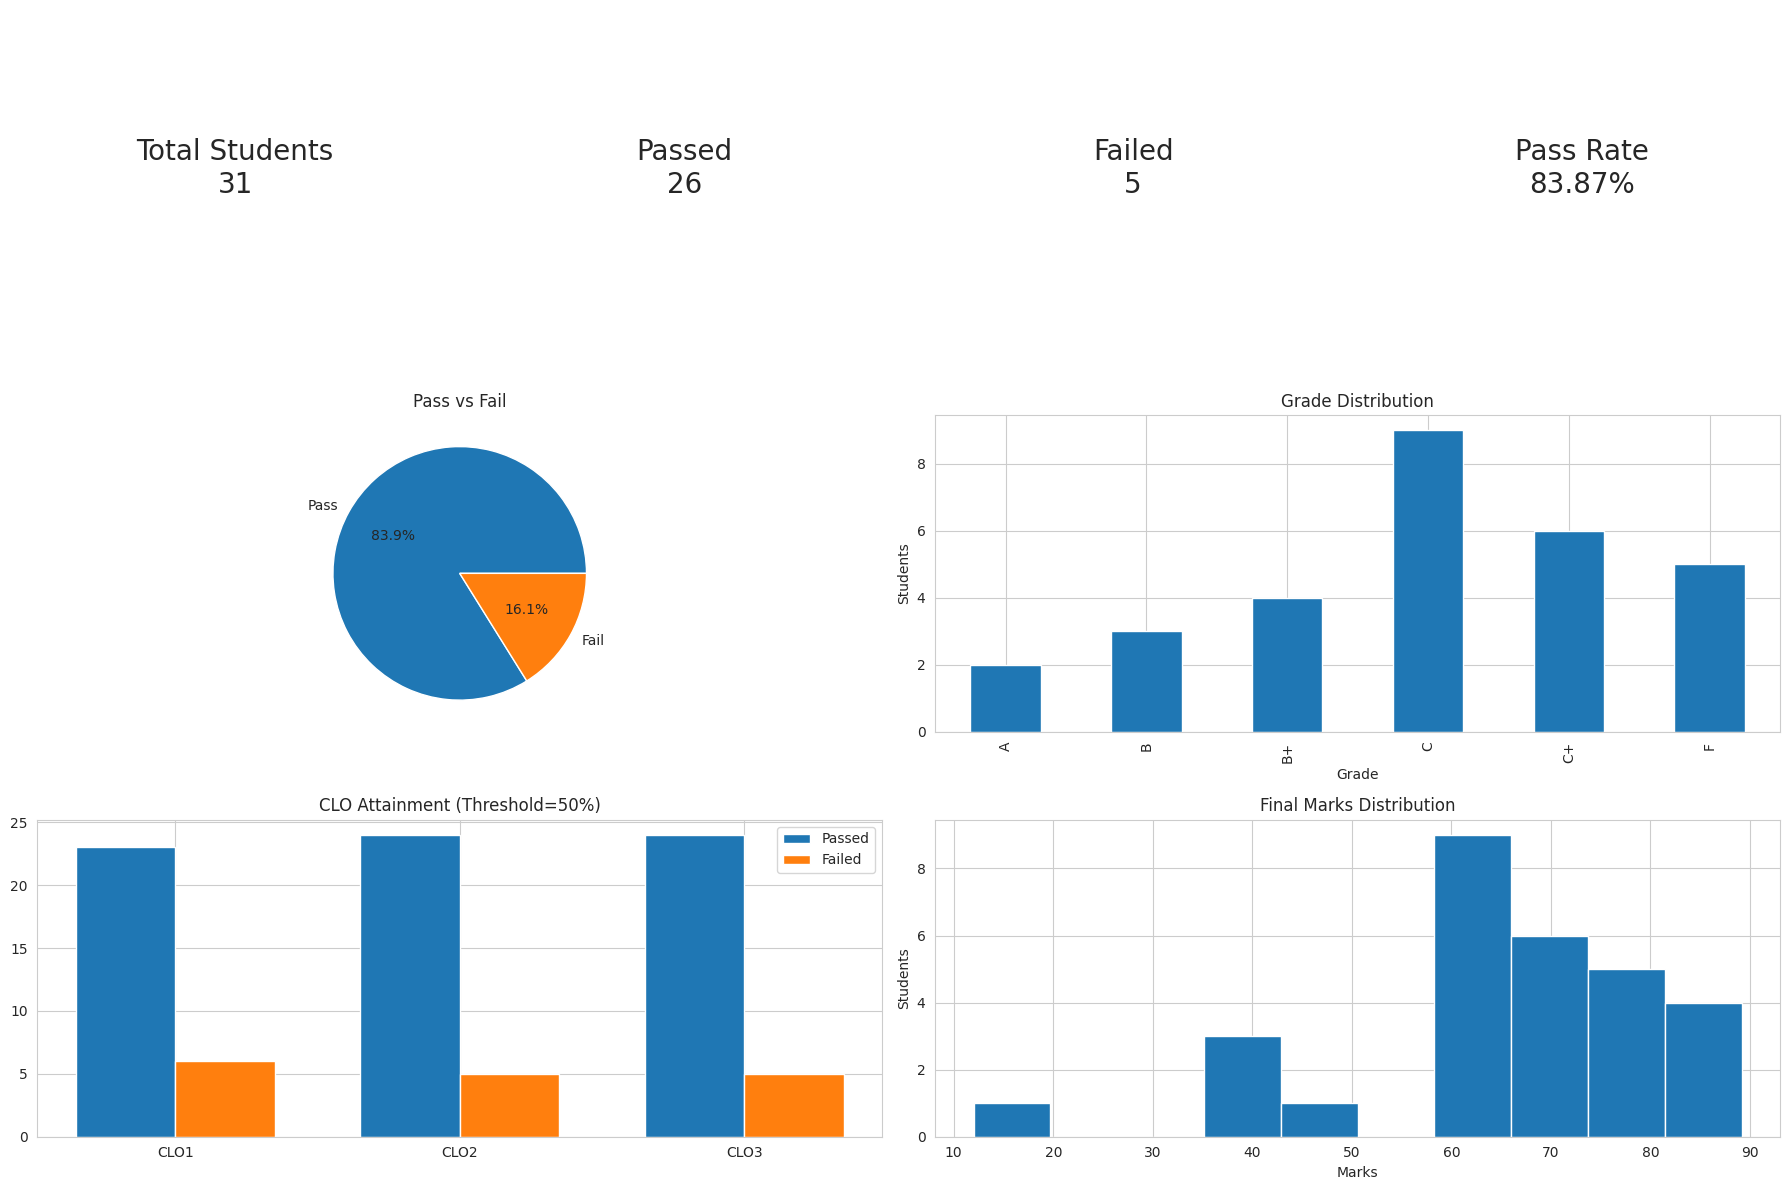

In [6]:
# =====================================================
# INTRO TO AI COURSE DASHBOARD
# Abdul Baqi Malik
# Google Colab Version
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# =====================================================
# Upload File
# =====================================================

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# =====================================================
# LOAD AWARD LIST
# =====================================================

award = pd.read_excel(
    file_name,
    sheet_name="Award List (Theory)",
    header=None
)

students = []

for i in range(14, len(award)):

    reg_no = award.iloc[i,2]

    if pd.isna(reg_no):
        continue

    students.append({
        "RegNo": reg_no,
        "Name": award.iloc[i,3],
        "FinalMarks": award.iloc[i,7],
        "Grade": award.iloc[i,8]
    })

award_df = pd.DataFrame(students)

# =====================================================
# PASS FAIL ANALYSIS
# =====================================================

award_df["Status"] = np.where(
    award_df["Grade"] == "F",
    "Fail",
    "Pass"
)

total_students = len(award_df)
passed_students = (award_df["Status"]=="Pass").sum()
failed_students = (award_df["Status"]=="Fail").sum()

pass_rate = round(
    passed_students/total_students*100,2
)

# =====================================================
# CLO ANALYSIS
# =====================================================

clo = pd.read_excel(
    file_name,
    sheet_name="Quantized Result",
    header=None
)

clo_data = clo.iloc[12:43,[1,2,3,4,5]]

clo_data.columns = [
    "RollNo",
    "Name",
    "CLO1",
    "CLO2",
    "CLO3"
]

clo_data = clo_data[
    clo_data["RollNo"].notna()
]

THRESHOLD = 50

clo_summary = pd.DataFrame({
    "CLO":["CLO1","CLO2","CLO3"],
    "Passed":[
        (clo_data["CLO1"]>=THRESHOLD).sum(),
        (clo_data["CLO2"]>=THRESHOLD).sum(),
        (clo_data["CLO3"]>=THRESHOLD).sum()
    ],
    "Failed":[
        (clo_data["CLO1"]<THRESHOLD).sum(),
        (clo_data["CLO2"]<THRESHOLD).sum(),
        (clo_data["CLO3"]<THRESHOLD).sum()
    ]
})

# =====================================================
# GRADE DISTRIBUTION
# =====================================================

grade_counts = (
    award_df["Grade"]
    .value_counts()
    .sort_index()
)

# =====================================================
# DASHBOARD
# =====================================================

fig = plt.figure(figsize=(18,12))

# -----------------------------------------------------
# KPI CARDS
# -----------------------------------------------------

ax1 = plt.subplot2grid((3,4),(0,0))
ax1.axis('off')
ax1.text(
    0.5,0.5,
    f"Total Students\n{total_students}",
    fontsize=20,
    ha='center',
    va='center'
)

ax2 = plt.subplot2grid((3,4),(0,1))
ax2.axis('off')
ax2.text(
    0.5,0.5,
    f"Passed\n{passed_students}",
    fontsize=20,
    ha='center',
    va='center'
)

ax3 = plt.subplot2grid((3,4),(0,2))
ax3.axis('off')
ax3.text(
    0.5,0.5,
    f"Failed\n{failed_students}",
    fontsize=20,
    ha='center',
    va='center'
)

ax4 = plt.subplot2grid((3,4),(0,3))
ax4.axis('off')
ax4.text(
    0.5,0.5,
    f"Pass Rate\n{pass_rate}%",
    fontsize=20,
    ha='center',
    va='center'
)

# -----------------------------------------------------
# PASS FAIL PIE CHART
# -----------------------------------------------------

ax5 = plt.subplot2grid((3,4),(1,0), colspan=2)

ax5.pie(
    [passed_students, failed_students],
    labels=["Pass","Fail"],
    autopct="%1.1f%%"
)

ax5.set_title("Pass vs Fail")

# -----------------------------------------------------
# GRADE DISTRIBUTION
# -----------------------------------------------------

ax6 = plt.subplot2grid((3,4),(1,2), colspan=2)

grade_counts.plot(
    kind='bar',
    ax=ax6
)

ax6.set_title("Grade Distribution")
ax6.set_ylabel("Students")

# -----------------------------------------------------
# CLO ATTAINMENT
# -----------------------------------------------------

ax7 = plt.subplot2grid((3,4),(2,0), colspan=2)

x = np.arange(len(clo_summary))

width = 0.35

ax7.bar(
    x-width/2,
    clo_summary["Passed"],
    width,
    label="Passed"
)

ax7.bar(
    x+width/2,
    clo_summary["Failed"],
    width,
    label="Failed"
)

ax7.set_xticks(x)
ax7.set_xticklabels(clo_summary["CLO"])
ax7.set_title(
    f"CLO Attainment (Threshold={THRESHOLD}%)"
)
ax7.legend()

# -----------------------------------------------------
# FINAL MARKS DISTRIBUTION
# -----------------------------------------------------

ax8 = plt.subplot2grid((3,4),(2,2), colspan=2)

ax8.hist(
    award_df["FinalMarks"],
    bins=10
)

ax8.set_title("Final Marks Distribution")
ax8.set_xlabel("Marks")
ax8.set_ylabel("Students")

plt.tight_layout()
plt.show()